# Distributed SNP: Paper Analysis & Visualization

This notebook generates the visualizations for the Distributed SNP paper.
It covers:
1. Scaling Benchmarks (Execution Time vs Input Size)
2. Distribution Benchmarks (Stability across input types)
3. Profiling Breakdown (MPI vs Compute)
4. Memory Hierarchy Analysis (L1/L2/DRAM usage)
5. Partitioning Strategy Comparison

## Implementations
- `cpu`
- `optimized-cuda`
- `sparse-cuda`
- `naive-cuda-mpi` (linear, louvain, red-blue)
- `optimized-cuda-mpi` (linear, louvain, red-blue)

In [22]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---

# Timestamps (Update these based on your runs)
TS_SCALING = "20260107_211932_SCALING_SNAPSHOT" # Pending
TS_DISTRIBUTION = "20260107_210341_DISTRIBUTION_SNAPSHOT" # Done
TS_NSYS = "20260107_214611_SNAPSHOT" # Pending
TS_NCU = "20260108_025939" # Pending

# Base Paths
BENCHMARK_RESULTS_DIR = Path("benchmark/results")
PROFILING_RESULTS_DIR = Path("profiling/results")
NSYS_DIR = PROFILING_RESULTS_DIR / "nsys" / TS_NSYS
NCU_DIR = PROFILING_RESULTS_DIR / "ncu" / TS_NCU

# Plotting Style for Paper (Two Column)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
    'font.family': 'serif' # Matching typical LaTeX font
})

# Color Palette
IMPL_COLORS = {
    'cpu': '#E74C3C',                   # Red
    'optimized-cuda': '#3498DB',        # Blue
    'sparse-cuda': '#9B59B6',           # Purple
    
    # Naive MPI (Greys/Silvers)
    'naive-cuda-mpi:linear': '#95A5A6',
    'naive-cuda-mpi:louvain': '#7F8C8D',
    'naive-cuda-mpi:red-blue': '#BDC3C7',
    
    # Optimized MPI (Greens/Teals)
    'optimized-cuda-mpi:linear': '#2ECC71',
    'optimized-cuda-mpi:louvain': '#27AE60',
    'optimized-cuda-mpi:red-blue': '#1ABC9C',
    
    # Generic mappings if exact match fails
    'naive-cuda-mpi': '#95A5A6',
    'optimized-cuda-mpi': '#27AE60'
}

print("✓ Configuration loaded.")

✓ Configuration loaded.


In [23]:
def load_benchmark_data(timestamp):
    """Parses Google Benchmark JSON output."""
    json_path = BENCHMARK_RESULTS_DIR / timestamp / "data.json"
    if not json_path.exists():
        print(f"⚠ Warning: Benchmark file not found: {json_path}")
        return pd.DataFrame()
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for bench in data['benchmarks']:
        name = bench['name']
        parts = name.split('/')
        # Format: Implementation/Distribution/Size/MaxVal/iterations...
        if len(parts) >= 3:
            impl = parts[0]
            dist = parts[1]
            try:
                size = int(parts[2])
            except ValueError:
                size = 0
            
            records.append({
                'Implementation': impl,
                'Distribution': dist,
                'Size': size,
                'RealTime': bench['real_time'], # Keep original unit (likely ns or ms)
                'TimeUnit': bench.get('time_unit', 'ns'),
                'RunType': bench.get('run_type', 'iteration')
            })
            
    df = pd.DataFrame(records)
    
    # Normalize Time to Milliseconds
    if not df.empty:
        # Google Benchmark often outputs in ns, but specifies 'ms' in time_unit
        # We'll normalize everything to MS
        def to_ms(row):
            t = row['RealTime']
            u = row['TimeUnit']
            if u == 'ns': return t / 1e6
            if u == 'us': return t / 1e3
            if u == 'ms': return t
            if u == 's': return t * 1e3
            return t
        
        df['TimeMS'] = df.apply(to_ms, axis=1)
        
    return df

def load_nsys_summary(impl_name, rank=0):
    """Loads aggregated Nsys stats for a specific implementation and rank."""
    base = NSYS_DIR / impl_name
    # Try getting statistics files
    # Need to handle different rank file naming patterns if necessary
    # Pattern: snp_profile_<host>_rank<rank>_stats_<type>.csv
    # We use glob to be safe
    
    # 1. GPU Kernel Time
    gpu_files = list(base.glob(f"*rank{rank}*stats_cuda_api_gpu_sum.csv"))
    if not gpu_files: 
        # Fallback for single rank without rank0 in name
        gpu_files = list(base.glob(f"*stats_cuda_api_gpu_sum.csv"))
        
    # 2. MPI Time
    mpi_files = list(base.glob(f"*rank{rank}*stats_mpi_event_sum.csv"))
    if not mpi_files:
        mpi_files = list(base.glob(f"*stats_mpi_event_sum.csv"))

    metrics = {'CUDA Kernel': 0, 'CUDA Memory': 0, 'MPI': 0, 'CPU': 0, 'Total': 0}
    
    if gpu_files:
        try:
            df_gpu = pd.read_csv(gpu_files[0])
            metrics['CUDA Kernel'] = df_gpu[df_gpu['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
            metrics['CUDA Memory'] = df_gpu[df_gpu['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        except Exception as e:
            print(f"  Error reading GPU file for {impl_name}: {e}")

    if mpi_files:
        try:
            df_mpi = pd.read_csv(mpi_files[0])
            metrics['MPI'] = df_mpi['Total Time (ns)'].sum()
        except Exception as e:
            pass # No MPI data is fine for non-MPI impls
            
    # For CPU/Total time, ideally we query the sqlite DB timeline.
    # As a simplification using CSVs only, we approximate Total = sum of parts + overhead?
    # Or better, we assume the benchmark runs reported Wall Time elsewhere, but here we want breakdown.
    # Let's approximate Total from the sum of components for the stacked bar
    # OR if we had total duration, CPU = Total - (GPU + MPI).
    # Since we lack the SQLite query capability in this simple extractor without complex logic,
    # let's assume valid CPU compute time is missing from these specific CSVs and focus on comparing
    # GPU vs MPI vs Memory costs, or try to infer.
    # The 'combined_analysis' script used SQLite for total time. 
    # Valid approximation: The sum of these parts is the "Device/Network Active Time".
    # We will display these components.
    
    return metrics

def load_ncu_metrics(impl_name):
    """Loads Ncu metrics CSV."""
    path = NCU_DIR / impl_name / "snp_profile_metrics.csv"
    if not path.exists(): return None
    
    try:
        # Skip unit row (index 1 in 0-based read, so row 2 in file)
        df = pd.read_csv(path, header=0)
        df = df.drop(0).reset_index(drop=True) # Drop unit row
        
        # Convert numeric
        cols_to_convert = [c for c in df.columns if 'sum' in c or 'avg' in c or 'pct' in c]
        for c in cols_to_convert:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            
        return df
    except Exception:
        return None

print("✓ Data loaders defined.")

✓ Data loaders defined.


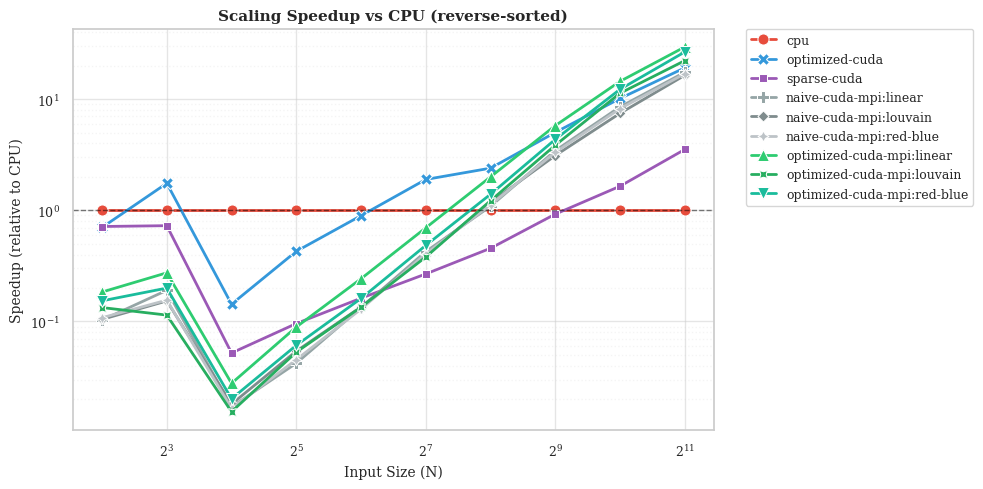

In [24]:
# --- 1. Scaling Benchmark Analysis (Speedup) ---

df_scale = load_benchmark_data(TS_SCALING)

if not df_scale.empty:
    # Filter for 'reverse-sorted' as it's the standard stress test
    # And run_type='iteration' to avoid aggregate stats
    target_dist = 'reverse-sorted'
    subset = df_scale[
        (df_scale['Distribution'] == target_dist) & 
        (df_scale['RunType'] == 'iteration')
    ].copy()
    
    if subset.empty:
        print(f"Warning: No data found for distribution '{target_dist}'. Using all available.")
        subset = df_scale.copy()
        
    # --- Calculate Speedup vs CPU ---
    # 1. Get CPU times for each size
    # We aggregate by mean if there are multiple iterations to ensure unique index for mapping
    cpu_subset = subset[subset['Implementation'] == 'cpu']
    cpu_times = cpu_subset.groupby('Size')['TimeMS'].mean()
    
    if not cpu_times.empty:
        # 2. Map CPU time to each row based on Size
        subset['CPU_Time'] = subset['Size'].map(cpu_times)
        
        # 3. Calculate Speedup
        subset['Speedup'] = subset['CPU_Time'] / subset['TimeMS']
        
        plt.figure(figsize=(10, 5)) 
        
        sns.lineplot(
            data=subset,
            x='Size', y='Speedup',
            hue='Implementation', style='Implementation',
            markers=True, dashes=False,
            palette=IMPL_COLORS,
            linewidth=2, markersize=8
        )
        
        plt.xscale('log', base=2)
        plt.yscale('log') # Speedups can be large
        
        plt.title(f'Scaling Speedup vs CPU ({target_dist})', fontweight='bold')
        plt.xlabel('Input Size (N)')
        plt.ylabel('Speedup (relative to CPU)')
        
        # Add baseline line
        plt.axhline(1, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.grid(True, which="major", ls="-", alpha=0.5)
        plt.grid(True, which="minor", ls=":", alpha=0.2)
        plt.tight_layout()
        plt.show()
    else:
        print("No CPU baseline found for speedup calculation.")
else:
    print("No scaling data found.")

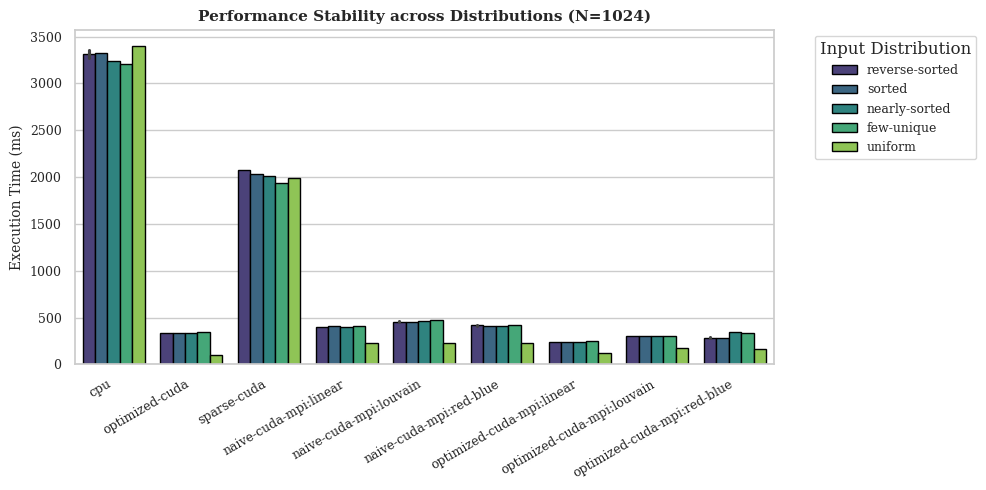

In [25]:
# --- 2. Distribution Stability Analysis ---

df_dist = load_benchmark_data(TS_DISTRIBUTION)

if not df_dist.empty:
    # Pick a common size to compare across distributions
    common_sizes = df_dist['Size'].mode()
    if not common_sizes.empty:
        target_size = common_sizes[0]
        subset_dist = df_dist[df_dist['Size'] == target_size].copy()
        
        plt.figure(figsize=(10, 5))
        
        sns.barplot(
            data=subset_dist,
            x='Implementation', y='TimeMS',
            hue='Distribution',
            palette='viridis',
            edgecolor='black'
        )
        
        plt.title(f'Performance Stability across Distributions (N={target_size})', fontweight='bold')
        plt.ylabel('Execution Time (ms)')
        plt.xlabel('')
        plt.xticks(rotation=30, ha='right')
        plt.legend(title='Input Distribution', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Could not determine common size for distribution comparison.")
else:
    print("No distribution data found.")

<Figure size 1000x600 with 0 Axes>

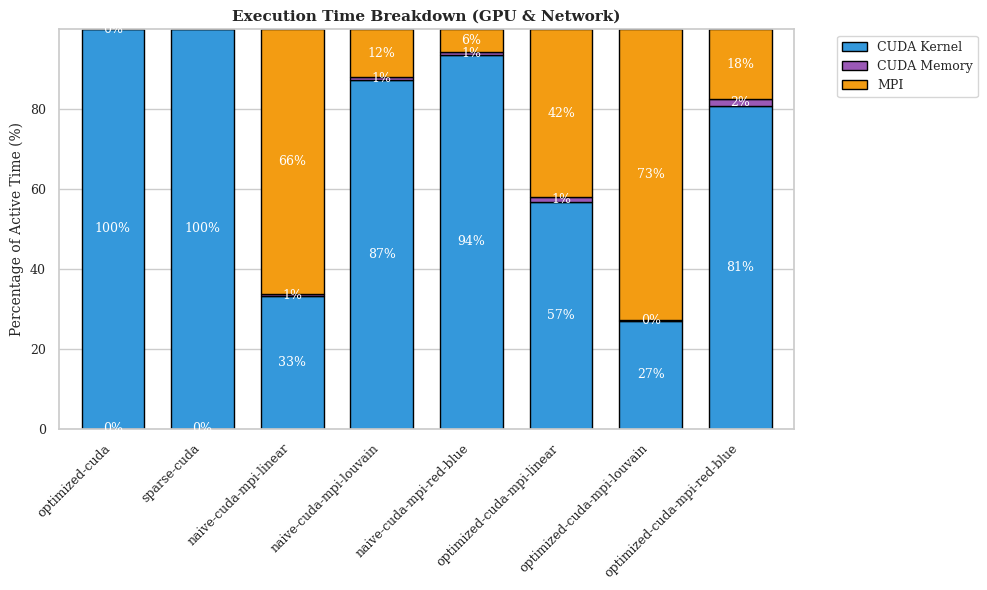

In [26]:
# --- 3. Profiling Breakdown (NSys) ---

# Implementations to check for profiling data
nsys_impls = [
    'optimized-cuda', 
    'sparse-cuda',
    'naive-cuda-mpi-linear', 
    'naive-cuda-mpi-louvain', 
    'naive-cuda-mpi-red-blue',
    'optimized-cuda-mpi-linear',
    'optimized-cuda-mpi-louvain',
    'optimized-cuda-mpi-red-blue'
]

breakdown_data = []

for impl in nsys_impls:
    # Check for rank 0 stats (usually the master rank)
    stats = load_nsys_summary(impl, rank=0)
    if stats['CUDA Kernel'] > 0 or stats['MPI'] > 0:
        breakdown_data.append({
            'Implementation': impl,
            'CUDA Kernel': stats['CUDA Kernel'],
            'CUDA Memory': stats['CUDA Memory'],
            'MPI': stats['MPI']
            # CPU time excluded as it requires timeline analysis not available in summary CSVs
        })

df_nsys = pd.DataFrame(breakdown_data)

if not df_nsys.empty:
    # Convert to Seconds
    for col in ['CUDA Kernel', 'CUDA Memory', 'MPI']:
        df_nsys[col] = df_nsys[col] / 1e9
        
    df_nsys.set_index('Implementation', inplace=True)
    
    # Calculate percentages for 100% stacked bar
    df_pct = df_nsys.div(df_nsys.sum(axis=1), axis=0) * 100
    
    plt.figure(figsize=(10, 6))
    
    # Plot Stacked Bar
    ax = df_pct.plot(
        kind='bar', stacked=True, 
        color=['#3498DB', '#9B59B6', '#F39C12'],
        edgecolor='black', width=0.7, figsize=(10, 6)
    )
    
    plt.title('Execution Time Breakdown (GPU & Network)', fontweight='bold')
    plt.ylabel('Percentage of Active Time (%)')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add labels
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=9)
        
    plt.tight_layout()
    plt.show()
else:
    print("No Nsys profiling data found.")

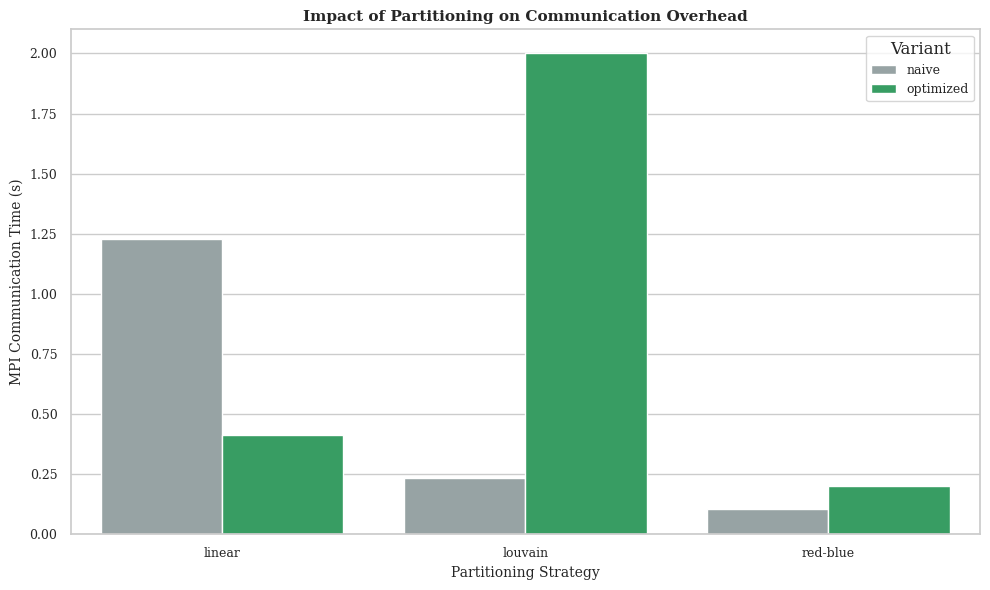

In [27]:
# --- 5. Partitioning Strategy Comparison ---

if 'df_nsys' in locals() and not df_nsys.empty:
    # Filter for MPI implementations
    mpi_df = df_nsys[df_nsys.index.str.contains('mpi')].copy()
    
    if not mpi_df.empty:
        # Extract Strategy and Variant
        def get_details(name):
            parts = name.split('-')
            # Ex: naive-cuda-mpi-linear -> Variant: naive, Strategy: linear
            # Ex: optimized-cuda-mpi-red-blue -> Variant: optimized, Strategy: red-blue
            variant = parts[0]
            strategy = '-'.join(parts[3:]) 
            return pd.Series([variant, strategy])
            
        mpi_df[['Variant', 'Strategy']] = mpi_df.index.to_series().apply(get_details)
        
        plt.figure(figsize=(10, 6))
        
        # Plot MPI Time Only
        sns.barplot(
            data=mpi_df.reset_index(),
            x='Strategy', y='MPI',
            hue='Variant',
            palette={'naive': '#95A5A6', 'optimized': '#27AE60'}
        )
        
        plt.title('Impact of Partitioning on Communication Overhead', fontweight='bold')
        plt.ylabel('MPI Communication Time (s)')
        plt.xlabel('Partitioning Strategy')
        plt.tight_layout()
        plt.show()
    else:
        print("No MPI data found for partitioning comparison.")
else:
    print("Nsys data unavailable. Cannot compare partitioning strategies.")

<Figure size 1000x600 with 0 Axes>

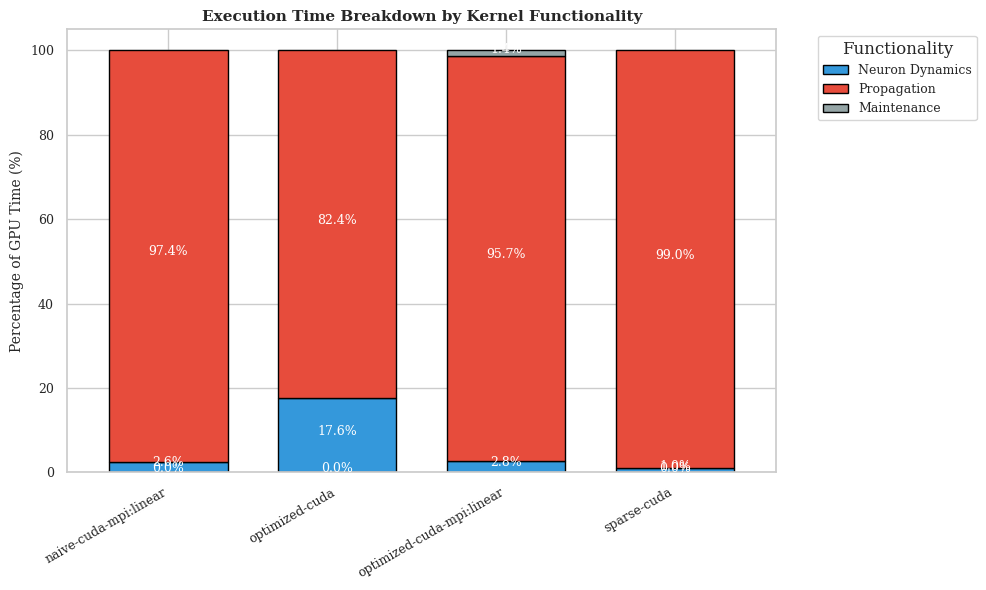

In [28]:
# --- 6. Kernel Functionality Comparison ---

# Mapping Kernels to High-Level Functions
KERNEL_FUNCTION_MAP = {
    # Dynamics
    'updateNeuronDynamicsKernel': 'Neuron Dynamics',
    'computeSpikingVectorKernel': 'Neuron Dynamics',
    
    # Propagation
    'propagateSpikesKernel': 'Propagation',
    'propagateLocalSpikesKernel': 'Propagation',
    'consumeSpikesAndProduceKernel': 'Propagation',
    'updateDelaysAndEmitKernel': 'Propagation',
    
    # MPI / Communication
    'populateExportBufferKernel': 'Propagation',
    'applyImportedSpikesKernel': 'Propagation',
    
    # Overhead / Maintenance
    'resetNeuronsKernel': 'Maintenance',
    'clearSpikeProductionKernel': 'Maintenance',
    'initializeKernel': 'Maintenance'
}

# Implementations to analyze
target_impls = [
    'optimized-cuda',
    'sparse-cuda', 
    'naive-cuda-mpi-linear',
    'optimized-cuda-mpi-linear'
]

kernel_data = []

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            print(f"Skipping {impl}: Metrics file not found.")
            continue
            
    try:
        # Read header to find units
        with open(metrics_path, 'r') as f:
            header = f.readline().strip().split(',')
            units = f.readline().strip().split(',')
            
        header = [h.replace('"', '') for h in header]
        units = [u.replace('"', '') for u in units]
        
        time_unit = 'us'
        if 'gpu__time_duration.sum' in header:
            idx = header.index('gpu__time_duration.sum')
            if idx < len(units):
                time_unit = units[idx]
        
        multiplier = 1.0
        if time_unit == 'us': multiplier = 1e-3
        elif time_unit == 'ns': multiplier = 1e-6
        elif time_unit == 's': multiplier = 1e3
        
        # Load Data
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        df['Kernel Name'] = df['Kernel Name'].astype(str).str.replace('"', '').str.strip()
        
        def clean_kernel_name(name):
            if '(' in name: name = name.split('(')[0]
            if '::' in name: name = name.split('::')[-1]
            return name.strip()
            
        df['CleanName'] = df['Kernel Name'].apply(clean_kernel_name)
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        df['TimeMS'] = pd.to_numeric(df['gpu__time_duration.sum'], errors='coerce') * multiplier
        
        grouped = df.groupby('Functionality')['TimeMS'].sum()
        
        for func, time_ms in grouped.items():
            color_key = impl.replace('-linear', ':linear')
            if color_key not in IMPL_COLORS and impl in IMPL_COLORS:
                color_key = impl
                
            kernel_data.append({
                'Implementation': color_key,
                'Functionality': func,
                'TimeMS': time_ms
            })
            
    except Exception as e:
        print(f"Error processing {impl}: {e}")

if kernel_data:
    df_kernel = pd.DataFrame(kernel_data)
    
    # Pivot to get Implementation as Index and Functionality as Columns
    df_pivot = df_kernel.pivot(index='Implementation', columns='Functionality', values='TimeMS').fillna(0)
    
    # Calculate Percentage
    df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    # Sort columns for logical display
    func_order = ['Neuron Dynamics', 'Propagation', 'MPI Communication', 'Maintenance', 'Other']
    existing_cols = [c for c in func_order if c in df_pct.columns]
    remaining_cols = [c for c in df_pct.columns if c not in func_order]
    df_pct = df_pct[existing_cols + remaining_cols]

    plt.figure(figsize=(10, 6))
    
    # Define color map for functionalities
    # Using a diverging or distinct palette
    FUNC_COLORS = {
        'Neuron Dynamics': '#3498DB',     # Blue
        'Propagation': '#E74C3C',         # Red
        'MPI Communication': '#2ECC71',   # Green
        'Maintenance': '#95A5A6',         # Grey
        'Other': '#F1C40F'                # Yellow
    }
    
    # Plot Stacked Bar
    ax = df_pct.plot(
        kind='bar', stacked=True, 
        color=[FUNC_COLORS.get(c, '#333333') for c in df_pct.columns],
        edgecolor='black', width=0.7, figsize=(10, 6)
    )
    
    plt.title('Execution Time Breakdown by Kernel Functionality', fontweight='bold')
    plt.ylabel('Percentage of GPU Time (%)')
    plt.xlabel('')
    plt.xticks(rotation=30, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Functionality')
    
    # Add labels
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=9, padding=3)

    plt.tight_layout()
    plt.show()
else:
    print("No kernel data available for comparison.")

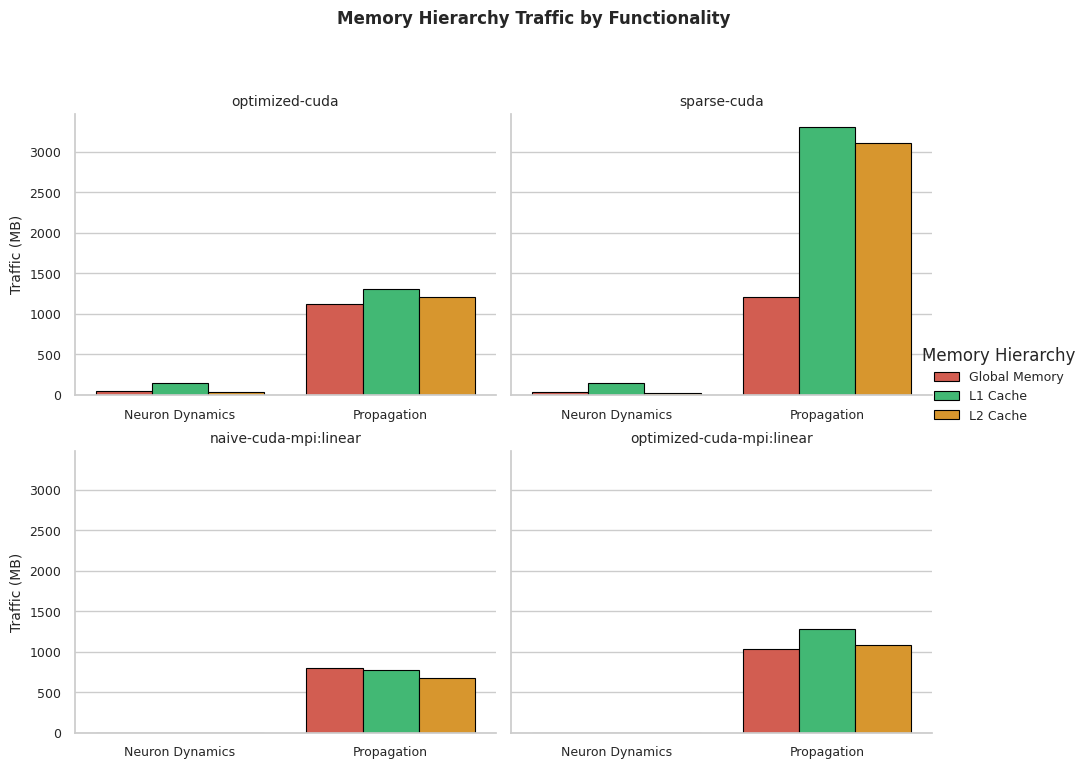

In [29]:
# --- 7. Memory Hierarchy Analysis by Functionality ---

# Ensure KERNEL_FUNCTION_MAP is defined

mem_data = []

# Target implementations (Same representatives as before)
target_impls = [
    'optimized-cuda',
    'sparse-cuda',
    'naive-cuda-mpi-linear',
    'optimized-cuda-mpi-linear'
]

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates:
            metrics_path = candidates[0]
        else:
            continue

    try:
        # Load Data
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        
        # Clean Names
        df['Kernel Name'] = df['Kernel Name'].astype(str).str.replace('"', '').str.strip()
        df['CleanName'] = df['Kernel Name'].apply(lambda x: x.split('(')[0].split('::')[-1].strip())
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')

        # Convert columns to numeric (Handle units carefully)
        # Expected Units from NCU 202x: 
        # dram__bytes...: Mbyte
        # l1tex__t_bytes...: Mbyte
        # lts__t_sectors...: sector (32 bytes)
        
        cols_check = [
            'dram__bytes_read.sum', 'dram__bytes_write.sum',
            'l1tex__t_bytes_lookup_hit.sum', 'l1tex__t_bytes_lookup_miss.sum',
            'lts__t_sectors_lookup_hit.sum', 'lts__t_sectors_lookup_miss.sum'
        ]
        
        # Ensure cols exist
        for c in cols_check:
            if c not in df.columns: df[c] = 0
            else: df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

        # Aggregate by Functionality
        group = df.groupby('Functionality')[cols_check].sum()
        
        for func, row in group.iterrows():
            dram_mb = row['dram__bytes_read.sum'] + row['dram__bytes_write.sum']
            l1_mb = row['l1tex__t_bytes_lookup_hit.sum'] + row['l1tex__t_bytes_lookup_miss.sum']
            l2_sectors = row['lts__t_sectors_lookup_hit.sum'] + row['lts__t_sectors_lookup_miss.sum']
            l2_mb = l2_sectors * 32.0 / 1e6 # 32 Bytes per sector -> MB
            
            color_key = impl.replace('-linear', ':linear')
            if color_key not in IMPL_COLORS and impl in IMPL_COLORS:
                color_key = impl

            mem_data.append({'Implementation': color_key, 'Functionality': func, 'Memory': 'Global Memory', 'TrafficMB': dram_mb})
            mem_data.append({'Implementation': color_key, 'Functionality': func, 'Memory': 'L1 Cache', 'TrafficMB': l1_mb})
            mem_data.append({'Implementation': color_key, 'Functionality': func, 'Memory': 'L2 Cache', 'TrafficMB': l2_mb})
            
    except Exception as e:
        print(f"Error {impl}: {e}")

if mem_data:
    df_mem_func = pd.DataFrame(mem_data)
    
    # Filter to main functional groups
    func_order = ['Neuron Dynamics', 'Propagation', 'MPI Communication']
    df_mem_func = df_mem_func[df_mem_func['Functionality'].isin(func_order)]
    
    # Visualize using FacetGrid
    sns.set_style("whitegrid")
    
    MEM_PALETTE = {
        'Global Memory': '#E74C3C', # Red (Slow)
        'L2 Cache': '#F39C12',      # Orange
        'L1 Cache': '#2ECC71'       # Green (Fast)
    }
    
    g = sns.catplot(
        data=df_mem_func,
        kind='bar',
        x='Functionality',
        y='TrafficMB',
        hue='Memory',
        col='Implementation',
        col_wrap=2,
        height=4, 
        aspect=1.2,
        palette=MEM_PALETTE,
        edgecolor='black',
        linewidth=0.8,
        sharex=False
    )
    
    g.set_axis_labels("", "Traffic (MB)")
    g.set_titles("{col_name}")
    g.set_xticklabels(rotation=0)
    g.legend.set_title("Memory Hierarchy")
    
    # Increase vertical spacing between rows to avoid label overlap
    plt.subplots_adjust(top=0.85, hspace=0.2)
    g.fig.suptitle('Memory Hierarchy Traffic by Functionality', fontweight='bold', y=0.98)
    plt.show()
else:
    print("No memory data found.")

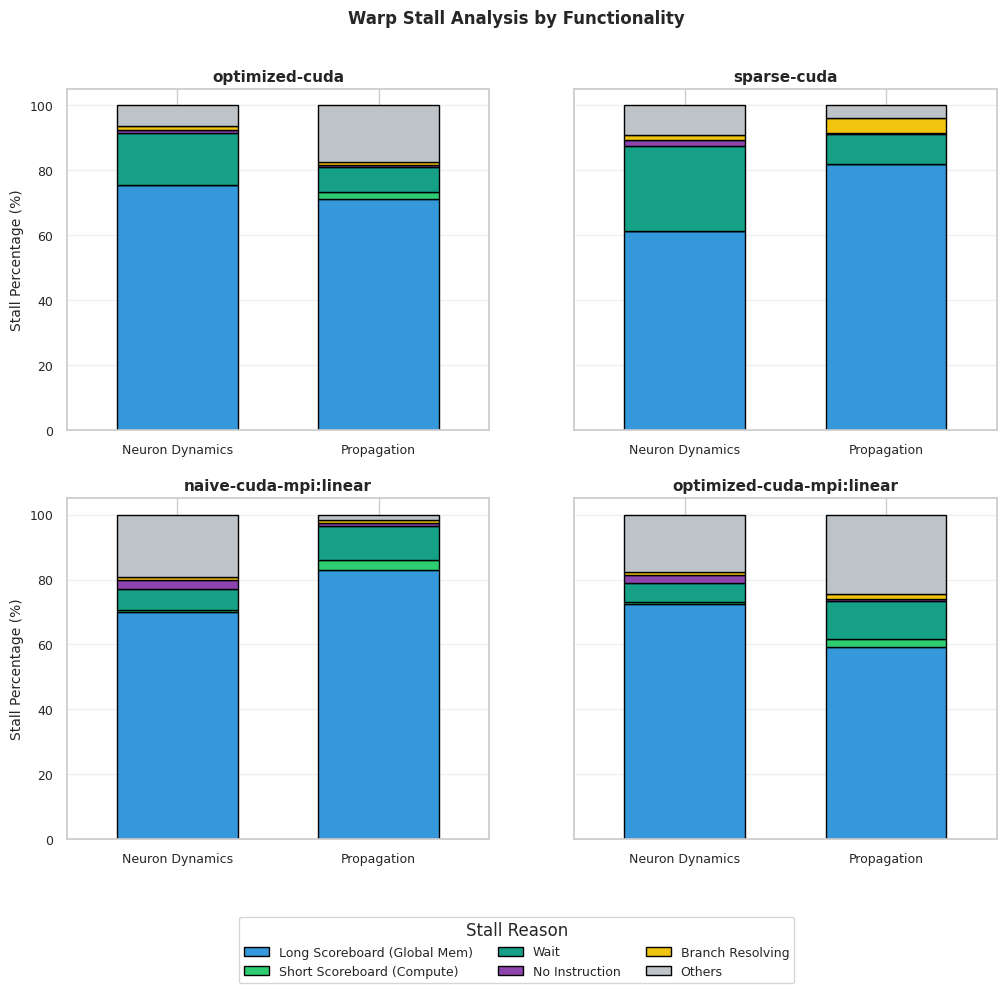

In [40]:
# --- 8. Warp Stall Analysis by Functionality ---

# Ensure KERNEL_FUNCTION_MAP is defined
if 'KERNEL_FUNCTION_MAP' not in locals():
    KERNEL_FUNCTION_MAP = {
        'updateNeuronDynamicsKernel': 'Neuron Dynamics',
        'computeSpikingVectorKernel': 'Neuron Dynamics',
        'propagateSpikesKernel': 'Propagation',
        'propagateLocalSpikesKernel': 'Propagation',
        'consumeSpikesAndProduceKernel': 'Propagation',
        'updateDelaysAndEmitKernel': 'Propagation',
        'populateExportBufferKernel': 'MPI Communication',
        'applyImportedSpikesKernel': 'MPI Communication',
        'resetNeuronsKernel': 'Maintenance',
        'clearSpikeProductionKernel': 'Maintenance',
        'initializeKernel': 'Maintenance'
    }

# Mapping specific NCU stall metrics to readable categories
# Note: Metric names must match CSV header exactly (after cleaning quotes)
STALL_METRICS = {
    # 'smsp__average_warps_issue_stalled_barrier_per_issue_active.pct': 'Barrier',
    'smsp__warp_issue_stalled_long_scoreboard_per_warp_active.pct': 'Long Scoreboard (Global Mem)',
    'smsp__warp_issue_stalled_short_scoreboard_per_warp_active.pct': 'Short Scoreboard (Compute)',
    'smsp__warp_issue_stalled_wait_per_warp_active.pct': 'Wait',
    # 'smsp__warp_issue_stalled_mio_throttle_per_warp_active.pct': 'MIO Throttle',
    # 'smsp__warp_issue_stalled_membar_per_warp_active.pct': 'Memory Barrier',
    'smsp__warp_issue_stalled_no_instruction_per_warp_active.pct': 'No Instruction',
    # 'smsp__warp_issue_stalled_math_pipe_throttle_per_warp_active.pct': 'Math Throttle', 
    # 'smsp__warp_issue_stalled_lg_throttle_per_warp_active.pct': 'LSU Throttle',
    'smsp__warp_issue_stalled_branch_resolving_per_warp_active.pct': 'Branch Resolving'
}

stall_data = []
target_impls = [
    'optimized-cuda',
    'sparse-cuda',
    'naive-cuda-mpi-linear',
    'optimized-cuda-mpi-linear'
]

for impl in target_impls:
    metrics_path = NCU_DIR / impl / "snp_profile_metrics.csv"
    if not metrics_path.exists():
        candidates = list((NCU_DIR / impl).glob("*rank0_metrics.csv"))
        if candidates: metrics_path = candidates[0]
        else: continue

    try:
        # Load Data
        df = pd.read_csv(metrics_path, header=0, skiprows=[1])
        
        # Clean Columns and Kernel Names
        df.columns = [c.replace('"', '').strip() for c in df.columns]
        df['Kernel Name'] = df['Kernel Name'].astype(str).str.replace('"', '').str.strip()
        df['CleanName'] = df['Kernel Name'].apply(lambda x: x.split('(')[0].split('::')[-1].strip())
        df['Functionality'] = df['CleanName'].map(KERNEL_FUNCTION_MAP).fillna('Other')
        
        # Duration for weighting
        if 'gpu__time_duration.sum' in df.columns:
            df['Duration'] = pd.to_numeric(df['gpu__time_duration.sum'], errors='coerce').fillna(0)
        else:
            continue # Can't weight without duration

        # Process each stall metric
        for col, label in STALL_METRICS.items():
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
                # Weighted contribution: Stall% * Duration
                df[f'{label}_weighted'] = df[col] * df['Duration']

        # Group by Functionality
        # We need to sum the weighted values and the duration, then divide
        agg_dict = {f'{label}_weighted': 'sum' for label in STALL_METRICS.values()}
        agg_dict['Duration'] = 'sum'
        
        grouped = df.groupby('Functionality')[list(agg_dict.keys())].sum()
        
        for func in ['Neuron Dynamics', 'Propagation', 'MPI Communication']:
            if func in grouped.index:
                total_dur = grouped.loc[func, 'Duration']
                if total_dur > 0:
                    total_pct = 0.0
                    color_key = impl.replace('-linear', ':linear')
                    if color_key not in IMPL_COLORS and impl in IMPL_COLORS: color_key = impl

                    for label in STALL_METRICS.values():
                        weighted_sum = grouped.loc[func, f'{label}_weighted']
                        avg_pct = weighted_sum / total_dur
                        total_pct += avg_pct
                        
                        stall_data.append({
                            'Implementation': color_key,
                            'Functionality': func,
                            'Stall Reason': label,
                            'Percentage': avg_pct
                        })
                    
                    # Add Others to reach 100%
                    stall_data.append({
                        'Implementation': color_key,
                        'Functionality': func,
                        'Stall Reason': 'Others',
                        'Percentage': max(0, 100.0 - total_pct)
                    })

    except Exception as e:
        print(f"Error {impl}: {e}")

if stall_data:
    df_stall = pd.DataFrame(stall_data)
    
    # Plotting
    # We will create a subplot for each implementation using Pandas plot for easy stacking
    unique_impls = df_stall['Implementation'].unique()
    n_impls = len(unique_impls)
    rows = (n_impls + 1) // 2
    
    fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows), sharey=True)
    axes = axes.flatten()
    
    STALL_COLORS = {
        'Barrier': '#E74C3C', # Red
        'Long Scoreboard (Global Mem)': '#3498DB', # Blue
        'Short Scoreboard (Compute)': '#2ECC71', # Green
        'Wait': '#16A085',  # Teal
        'MIO Throttle': '#7F8C8D', # Dark Grey
        'Memory Barrier': '#E67E22', # Orange
        'No Instruction': '#8E44AD', # Purple
        'Math Throttle': '#D35400', # Dark Orange
        'LSU Throttle': '#95A5A6', # Grey
        'Branch Resolving': '#F1C40F', # Yellow
        'Others': '#BDC3C7' # Light Grey
    }
    
    for idx, impl in enumerate(unique_impls):
        ax = axes[idx]
        subset = df_stall[df_stall['Implementation'] == impl]
        
        # Pivot for stacked bar: Index=Functionality, Col=Stall Reason
        pivot = subset.pivot(index='Functionality', columns='Stall Reason', values='Percentage').fillna(0)
        
        # Reorder columns to align with colors
        cols = [c for c in STALL_COLORS.keys() if c in pivot.columns]
        pivot = pivot[cols]
        colors = [STALL_COLORS[c] for c in pivot.columns]
        
        pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', width=0.6, legend=False)
        
        ax.set_title(impl, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Stall Percentage (%)' if idx % 2 == 0 else '')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for i in range(idx + 1, len(axes)):
        axes[i].axis('off')

    # Add shared legend at bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Stall Reason', loc='lower center', 
               bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=True)

    plt.subplots_adjust(hspace=0.2, top=0.9, bottom=0.15)
    fig.suptitle('Warp Stall Analysis by Functionality', fontweight='bold')
    plt.show()
else:
    print("No stall data found.")